# Top Product Categories by Revenue
Identifying which product categories drive the most revenue on Olist.

In [1]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

client = bigquery.Client(project='dataai-project-0')

E0000 00:00:1780301144.928647  154553 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1780301144.928822  154553 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_rejected' registered more than once. Ignoring later registration.
E0000 00:00:1780301144.928839  154553 instrument.cc:563] Metric with name 'grpc.resource_quota.connections_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1780301144.928848  154553 instrument.cc:563] Metric with name 'grpc.resource_quota.instantaneous_memory_pressure' registered more than once. Ignoring later registration.
E0000 00:00:1780301144.928862  154553 instrument.cc:563] Metric with name 'grpc.resource_quota.memory_pressure_control_value' registered more than once. Ignoring later registration.


## EDA — Sanity Checks

In [3]:
eda = client.query("""
    SELECT
        COUNT(DISTINCT f.product_id)        AS unique_products,
        COUNT(DISTINCT p.category)          AS unique_categories,
        COUNTIF(p.category IS NULL)         AS null_categories,
        ROUND(SUM(f.total_amount), 2)       AS total_revenue
    FROM `dataai-project-0.gold.fact_orders` f
    LEFT JOIN `dataai-project-0.gold.dim_product` p ON f.product_id = p.product_id
""").to_dataframe()

print(eda.to_string(index=False))

/home/seanwong/miniconda3/envs/elt/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


 unique_products  unique_categories  null_categories  total_revenue
           32951                 71             1627    15843553.24


## Analysis — Revenue by Category

In [4]:
df = client.query("""
    SELECT
        COALESCE(p.category, 'Unknown')         AS category,
        ROUND(SUM(f.total_amount), 2)           AS revenue,
        COUNT(DISTINCT f.order_id)              AS orders,
        ROUND(AVG(f.total_amount), 2)           AS avg_order_value
    FROM `dataai-project-0.gold.fact_orders` f
    LEFT JOIN `dataai-project-0.gold.dim_product` p ON f.product_id = p.product_id
    GROUP BY 1
    ORDER BY 2 DESC
""").to_dataframe()

df.head(10)

/home/seanwong/miniconda3/envs/elt/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,category,revenue,orders,avg_order_value
0,health_beauty,1441248.07,8836,149.04
1,watches_gifts,1305541.61,5624,217.92
2,bed_bath_table,1241681.72,9417,111.71
3,sports_leisure,1156656.48,7720,133.86
4,computers_accessories,1059272.40,6689,135.34
5,furniture_decor,902511.79,6449,108.29
6,housewares,778397.77,5884,111.77
7,cool_stuff,719329.95,3632,189.50
8,auto,685384.32,3897,161.84
9,garden_tools,584219.21,3518,134.40


## Key Metrics

In [5]:
total_revenue = df['revenue'].sum()
top3_revenue = df.head(3)['revenue'].sum()
top10_revenue = df.head(10)['revenue'].sum()

df['revenue_share'] = (df['revenue'] / total_revenue * 100).round(2)

print(f"Total revenue: R$ {total_revenue:,.2f}")
print(f"Top 3 categories: R$ {top3_revenue:,.2f} ({top3_revenue/total_revenue*100:.1f}% of total)")
print(f"Top 10 categories: R$ {top10_revenue:,.2f} ({top10_revenue/total_revenue*100:.1f}% of total)")
print(f"\nTop 10 categories by revenue:")
print(df[['category', 'revenue', 'revenue_share', 'orders', 'avg_order_value']].head(10).to_string(index=False))

Total revenue: R$ 15,843,553.24
Top 3 categories: R$ 3,988,471.40 (25.2% of total)
Top 10 categories: R$ 9,874,243.32 (62.3% of total)

Top 10 categories by revenue:
             category    revenue  revenue_share  orders  avg_order_value
        health_beauty 1441248.07           9.10    8836           149.04
        watches_gifts 1305541.61           8.24    5624           217.92
       bed_bath_table 1241681.72           7.84    9417           111.71
       sports_leisure 1156656.48           7.30    7720           133.86
computers_accessories 1059272.40           6.69    6689           135.34
      furniture_decor  902511.79           5.70    6449           108.29
           housewares  778397.77           4.91    5884           111.77
           cool_stuff  719329.95           4.54    3632           189.50
                 auto  685384.32           4.33    3897           161.84
         garden_tools  584219.21           3.69    3518           134.40


## Visualisation

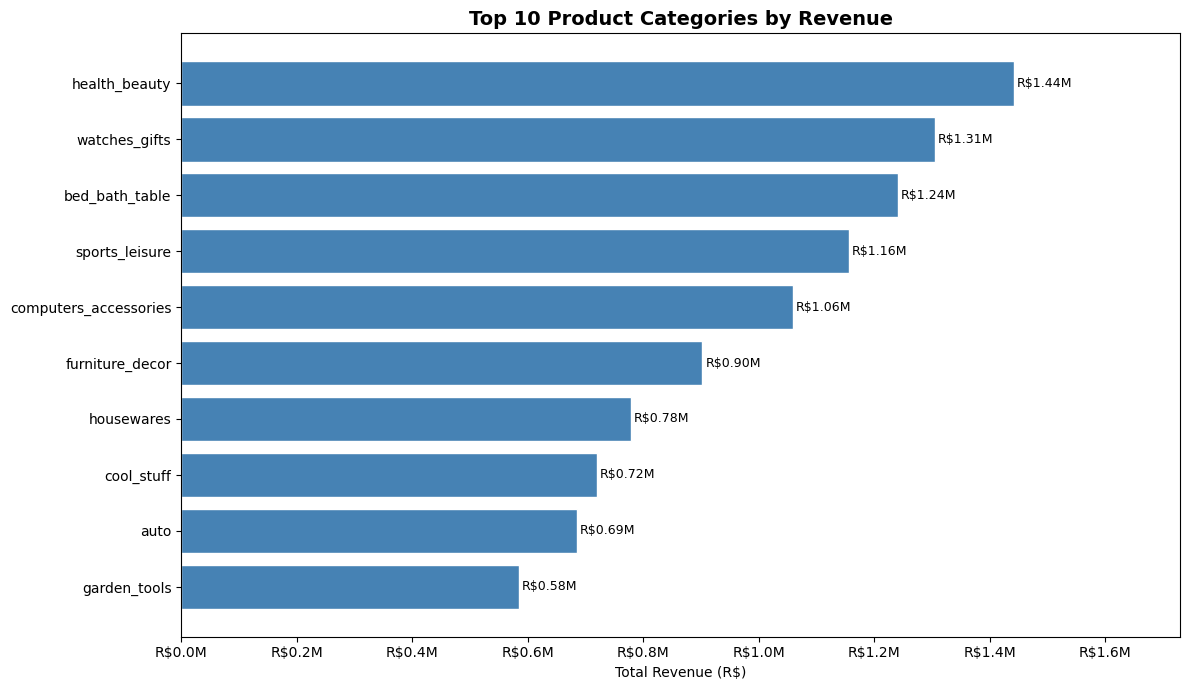

In [6]:
top10 = df.head(10).sort_values('revenue')

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(top10['category'], top10['revenue'], color='steelblue', edgecolor='white')

for bar, val in zip(bars, top10['revenue']):
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
            f'R${val/1e6:.2f}M', va='center', fontsize=9)

ax.set_xlabel('Total Revenue (R$)')
ax.set_title('Top 10 Product Categories by Revenue', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
ax.set_xlim(0, top10['revenue'].max() * 1.2)

plt.tight_layout()
plt.savefig('top_categories.png', dpi=150, bbox_inches='tight')
plt.show()

## Business Recommendation

**Finding:** Revenue is highly concentrated — the top 3 categories account for a disproportionate share of total revenue, while the long tail of categories contributes relatively little individually.

**Recommendation:** Olist should prioritise seller acquisition and promotional spend in the top 3 categories to defend and grow the core revenue base. Simultaneously, identify 2–3 high-potential mid-tier categories with strong order volume but lower average order value — these represent the best opportunity to grow revenue through seller quality improvements and upselling strategies.